# Football Player Evaluation Model - Analysis



## 0. Setup - Imports and Configuration

In [29]:
import pandas as pd
import tensorflow as tf

import config
from src.analysis.game_utils import game_summary
from src.data.data_loader import load_statsbomb_socceraction_data
from src.ml.models.model_factory import load_model
from src.ml.preprocessing.sequence import SequencePreprocessor
from src.ml.xthreat import get_default_xt_model
from src.analysis.prediction_utils import get_top_indices, normalize_predictions, print_top_predictions, visualize_top_possessions, visualize_top_possessions_matches


In [30]:
# Configure pandas display options
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 1. Load and Split Data

In [31]:
data = load_statsbomb_socceraction_data("data/statsbomb/data", 55, 282)
all_matches = list(data)

# Sort matches by game_date
all_matches.sort(key=lambda x: x[0].get('game_date', ''), reverse=True)

len(all_matches)


Found 51 matches in competition 55, season 282
Loading events for match 3942819 (1/51)...
Loading events for match 3943043 (2/51)...
Loading events for match 3942752 (3/51)...
Loading events for match 3942382 (4/51)...
Loading events for match 3942349 (5/51)...
Loading events for match 3930180 (6/51)...
Loading events for match 3930171 (7/51)...
Loading events for match 3942227 (8/51)...
Loading events for match 3942226 (9/51)...
Loading events for match 3938645 (10/51)...
Loading events for match 3930184 (11/51)...
Loading events for match 3941022 (12/51)...
Loading events for match 3941021 (13/51)...
Loading events for match 3941020 (14/51)...
Loading events for match 3941019 (15/51)...
Loading events for match 3941018 (16/51)...
Loading events for match 3941017 (17/51)...
Loading events for match 3930182 (18/51)...
Loading events for match 3930179 (19/51)...
Loading events for match 3940983 (20/51)...
Loading events for match 3940878 (21/51)...
Loading events for match 3930177 (22/5

51

### 1.1 Validation Set Matches Information

In [32]:
matches_info = []

for match, events_df in all_matches:
    matches_info.append(game_summary(match))

for match in matches_info:
    print(match)


Spain 2 : 1 England (Final) [14.07.2024]
Netherlands 1 : 2 England (Semi-finals) [10.07.2024]
Spain 2 : 1 France (Semi-finals) [09.07.2024]
Netherlands 2 : 1 Turkey (Quarter-finals) [06.07.2024]
England 1 : 1 Switzerland (Quarter-finals) [06.07.2024]
Portugal 0 : 0 France (Quarter-finals) [05.07.2024]
Spain 2 : 1 Germany (Quarter-finals) [05.07.2024]
Austria 1 : 2 Turkey (Round of 16) [02.07.2024]
Romania 0 : 3 Netherlands (Round of 16) [02.07.2024]
Portugal 0 : 0 Slovenia (Round of 16) [01.07.2024]
France 1 : 0 Belgium (Round of 16) [01.07.2024]
Spain 4 : 1 Georgia (Round of 16) [30.06.2024]
England 2 : 1 Slovakia (Round of 16) [30.06.2024]
Germany 2 : 0 Denmark (Round of 16) [29.06.2024]
Switzerland 2 : 0 Italy (Round of 16) [29.06.2024]
Czech Republic 1 : 2 Turkey (Group Stage) [26.06.2024]
Georgia 2 : 0 Portugal (Group Stage) [26.06.2024]
Ukraine 0 : 0 Belgium (Group Stage) [26.06.2024]
Slovakia 1 : 1 Romania (Group Stage) [26.06.2024]
Denmark 0 : 0 Serbia (Group Stage) [25.06.2024

## 2. Load Trained Model

In [33]:
# Load the best trained model
MODEL_TYPE = 'lstm'
model = load_model(MODEL_TYPE)
print(f"Model type: {MODEL_TYPE}")


Model type: lstm


In [34]:
# Display model architecture
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6, 45)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 6, 128)         │        89,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 428,165 (1.63 MB)

 Trainable params: 142,721 (557.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 285,444 (1.09 MB)

## 3. Preprocess Data for Analysis

In [35]:
# Initialize preprocessor
preprocessor = SequencePreprocessor(
    sequence_length=config.SEQUENCE_LENGTH,
    xt_model=get_default_xt_model()
)

# Process validation set for analysis
X, y, p, m = preprocessor.process_matches(all_matches)
print(f"Validation set preprocessed: {X.shape[0]} sequences")


→Processing match 3943043: 3312 events
 → Generated 86 sequences, 86 labels for match 3943043
→Processing match 3942819: 3485 events
 → Generated 82 sequences, 82 labels for match 3942819
→Processing match 3942752: 3328 events
 → Generated 107 sequences, 107 labels for match 3942752
→Processing match 3942382: 3415 events
 → Generated 91 sequences, 91 labels for match 3942382
→Processing match 3942227: 4882 events
 → Generated 105 sequences, 105 labels for match 3942227
→Processing match 3942349: 5190 events
 → Generated 131 sequences, 131 labels for match 3942349
→Processing match 3942226: 4463 events
 → Generated 138 sequences, 138 labels for match 3942226
→Processing match 3941022: 3722 events
 → Generated 104 sequences, 104 labels for match 3941022
→Processing match 3941021: 2996 events
 → Generated 98 sequences, 98 labels for match 3941021
→Processing match 3941020: 4221 events
 → Generated 124 sequences, 124 labels for match 3941020
→Processing match 3941019: 3941 events
 → Genera

In [36]:
X.shape

(5277, 6, 45)

In [37]:
p.shape

(5277,)

In [38]:
p[0:200]

array([  3,   4,   5,   6,   7,   8,   9,  12,  15,  17,  19,  21,  24,
        26,  27,  29,  30,  31,  32,  33,  34,  36,  40,  42,  43,  44,
        46,  48,  49,  50,  51,  52,  56,  58,  60,  61,  62,  63,  64,
        65,  66,  67,  69,  74,  79,  80,  81,  83,  84,  85,  87,  89,
        90,  91,  92,  94,  96,  97,  98,  99, 100, 102, 104, 105, 106,
       109, 110, 111, 112, 113, 117, 119, 120, 121, 123, 125, 127, 129,
       130, 132, 133, 134, 135, 136, 137, 144,   2,   4,   5,   6,   7,
         8,   9,  10,  11,  12,  13,  16,  17,  18,  22,  23,  24,  26,
        27,  28,  30,  31,  32,  33,  34,  36,  38,  40,  42,  44,  45,
        47,  48,  49,  51,  52,  53,  54,  55,  56,  58,  59,  60,  61,
        62,  63,  64,  65,  66,  67,  68,  70,  71,  72,  73,  74,  75,
        76,  77,  79,  81,  85,  86,  88,  89,  90,  92,  93,  94,  95,
        96,  97,  98,  99, 100, 103, 104, 106, 109, 110, 111, 113,   2,
         3,   4,   5,   7,   8,   9,  11,  12,  13,  14,  15,  1

## 4. Analysis


### 4.1 Single Match Analysis - Final Match

#### Load and analyze the final match

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from src.ml.preprocessing.possessions_extraction import extract_possessions, tail_dataframes_to_sequence_length
selected_match, selected_events = all_matches[0]
selected_match_id = selected_match.get('match_id', selected_match.get('game_id', 'N/A'))

print(f"\nAnalyzing match: {game_summary(selected_match)}")
print(f"Events in match: {len(selected_events)}")



Analyzing match: Spain 2 : 1 England (Final) [14.07.2024]
Events in match: 3312


#### Preprocess match into sequences

In [40]:
preprocessor_analysis = SequencePreprocessor(
    sequence_length=config.SEQUENCE_LENGTH,
    xt_model=get_default_xt_model()
)

X_match, y_match, p_match = preprocessor_analysis.process_match(selected_match_id, selected_match, selected_events)
print(f"Created {len(X_match)} sequences from {len(selected_events)} events")


→Processing match 3943043: 3312 events
 → Generated 86 sequences, 86 labels for match 3943043
Created 86 sequences from 3312 events


#### Make predictions on match sequences

In [41]:
predictions = model.predict(X_match, batch_size=32, verbose=0)
predictions

array([[ 7.78064691e-03],
       [ 1.12938089e-02],
       [ 6.39573857e-03],
       [-2.68921256e-04],
       [ 1.05657876e-02],
       [ 3.57156619e-03],
       [ 2.95528397e-02],
       [ 4.63828892e-02],
       [ 7.60370307e-03],
       [ 1.01447869e-02],
       [ 8.63468647e-03],
       [ 5.32161482e-02],
       [ 2.41849348e-02],
       [ 4.07480635e-02],
       [ 1.40736867e-02],
       [ 1.28376577e-02],
       [ 1.24753071e-02],
       [ 4.97510843e-03],
       [ 1.43694831e-02],
       [-3.17087024e-03],
       [ 5.72120864e-03],
       [ 1.11913569e-02],
       [ 3.15712765e-02],
       [ 2.26370301e-02],
       [ 1.05968248e-02],
       [ 4.75862511e-02],
       [ 1.91164277e-02],
       [-1.35378167e-03],
       [ 1.08181406e-02],
       [ 1.56624038e-02],
       [ 1.90123916e-04],
       [ 5.66597097e-03],
       [ 1.34426989e-02],
       [ 2.82111727e-02],
       [ 1.37601327e-02],
       [ 3.11828032e-03],
       [ 8.13389104e-03],
       [ 9.88086592e-03],
       [ 1.3

#### Predictions

In [42]:
predicted_values, attention_weights = normalize_predictions(predictions)
print(f"Total sequences analyzed: {len(predicted_values)}")
print(f"Sum of all predicted values: {predicted_values.sum():.3f}")
print(f"Has attention weights: {attention_weights is not None}")

Total sequences analyzed: 86
Sum of all predicted values: 2.578
Has attention weights: False


#### LSTM Attention Weights and Predicted Values

#### Get top 8 sequences by predicted value

In [43]:
number_of_top_predictions = 8
print_top_predictions(predicted_values, p_match, None, number_of_top_predictions, attention_weights)


Top 8 sequences with highest predicted values:

1. Possession id = 136: Value = 0.305

2. Possession id = 81: Value = 0.304

3. Possession id = 117: Value = 0.233

4. Possession id = 83: Value = 0.117

5. Possession id = 69: Value = 0.101

6. Possession id = 106: Value = 0.093

7. Possession id = 105: Value = 0.087

8. Possession id = 74: Value = 0.068



#### Visualize top 8 possessions on the pitch

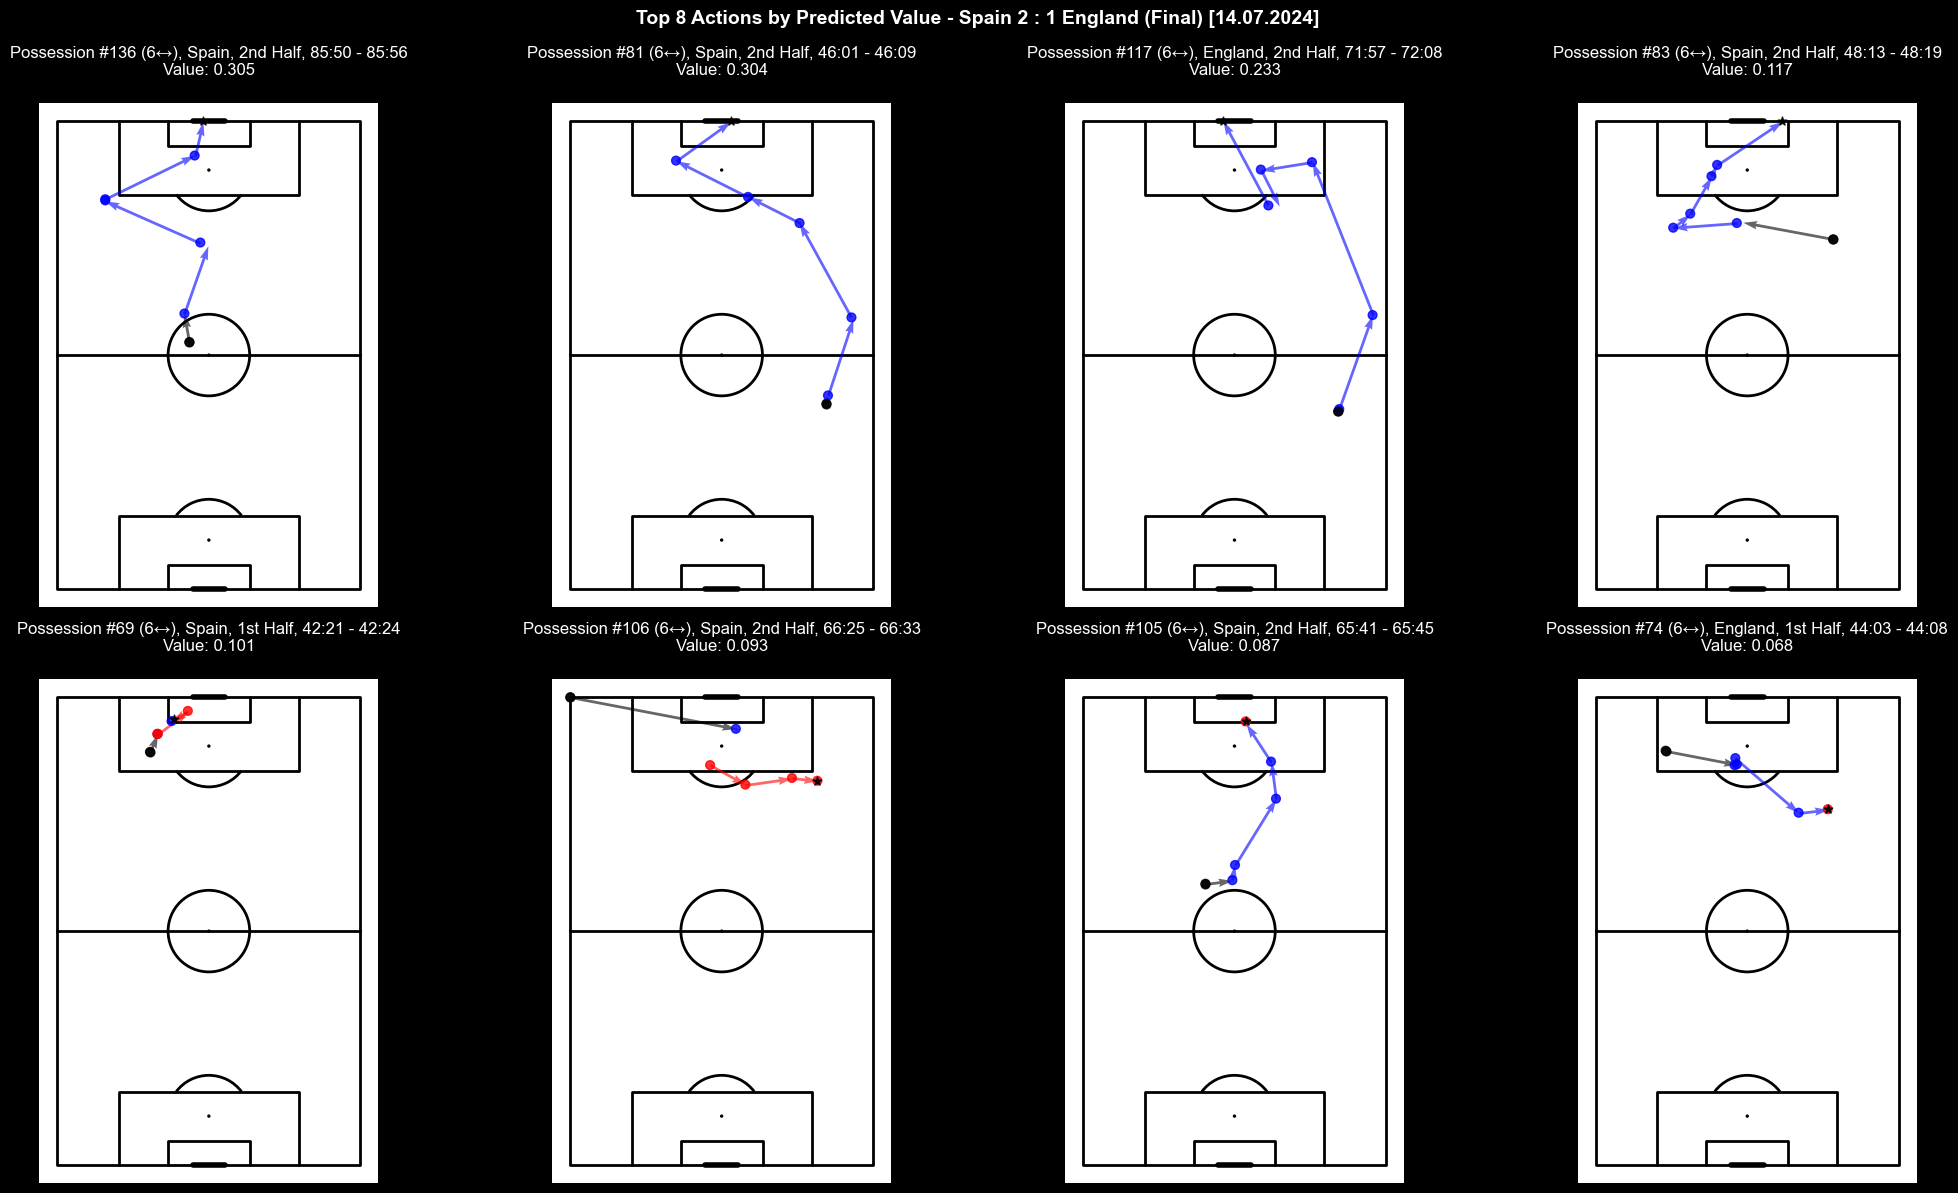

In [44]:
from src.analysis.visualization import plot_multiple_possessions, _title_with_value


top_indices = get_top_indices(predicted_values, number_of_top_predictions)

top_possessions = [extract_possessions(selected_match, selected_events)[p_match[idx]] for idx in top_indices]
top_possessions = tail_dataframes_to_sequence_length(top_possessions, config.SEQUENCE_LENGTH)

top_possession_titles = []
for i, idx in enumerate(top_indices):
    possession = top_possessions[i]
    attention_weight = attention_weights[idx] if attention_weights is not None else None
    top_possession_titles.append(_title_with_value(possession, predicted_values[idx], attention_weight))

fig = plot_multiple_possessions(top_possessions, titles=top_possession_titles,
                                main_title=f"Top {number_of_top_predictions} Actions by Predicted Value - {game_summary(selected_match)}")
plt.tight_layout()
plt.show()


### 4.2 All Matches Analysis

#### Extract match information from all matches

In [45]:
from src.analysis.prediction_utils import matches_info_df

matches_df = matches_info_df(all_matches)
matches_df.head(10)

,match_id,summary,events_count
0,3943043,Spain 2 : 1 England (Final) [14.07.2024],3312
1,3942819,Netherlands 1 : 2 England (Semi-finals) [10.07.2024],3485
2,3942752,Spain 2 : 1 France (Semi-finals) [09.07.2024],3328
3,3942382,Netherlands 2 : 1 Turkey (Quarter-finals) [06.07.2024],3415
4,3942227,England 1 : 1 Switzerland (Quarter-finals) [06.07.2024],4882
5,3942349,Portugal 0 : 0 France (Quarter-finals) [05.07.2024],5190
6,3942226,Spain 2 : 1 Germany (Quarter-finals) [05.07.2024],4463
7,3941022,Austria 1 : 2 Turkey (Round of 16) [02.07.2024],3722
8,3941021,Romania 0 : 3 Netherlands (Round of 16) [02.07.2024],2996
9,3941020,Portugal 0 : 0 Slovenia (Round of 16) [01.07.2024],4221


#### Predictions for all matches

In [46]:
predictions = model.predict(X, batch_size=32, verbose=0)

In [47]:
predicted_values, attention_weights = normalize_predictions(predictions)
print(f"Total sequences analyzed: {len(predicted_values)}")
print(f"Sum of all predicted values: {predicted_values.sum():.3f}")
print(f"Has attention weights: {attention_weights is not None}")

Total sequences analyzed: 5277
Sum of all predicted values: 138.422
Has attention weights: False


#### Get top 8 sequences by predicted value across all matches

In [48]:
number_of_top_predictions = 8
print_top_predictions(predicted_values, p, m, number_of_top_predictions, attention_weights)


Top 8 sequences with highest predicted values:

1. Match ID = 3930160, Possession ID = 105: Value = 1.478

2. Match ID = 3930170, Possession ID = 69: Value = 0.733

3. Match ID = 3930184, Possession ID = 107: Value = 0.659

4. Match ID = 3930178, Possession ID = 77: Value = 0.531

5. Match ID = 3938638, Possession ID = 93: Value = 0.492

6. Match ID = 3938641, Possession ID = 61: Value = 0.450

7. Match ID = 3942819, Possession ID = 94: Value = 0.444

8. Match ID = 3942227, Possession ID = 105: Value = 0.435



#### Prepare possessions for all matches

In [ ]:
from src.analysis.prediction_utils import create_possessions_list
import gc

game_possessions_list = create_possessions_list(all_matches)
del all_matches
gc.collect()

#### Visualize top 8 possessions from validation set on the pitch

In [ ]:
visualize_top_possessions_matches(game_possessions_list, p, m, predicted_values, attention_weights, number_of_top_predictions, config.SEQUENCE_LENGTH)
plt.savefig(f"models/{MODEL_TYPE}/top_possessions_all_matches.png", dpi=300)
